# Data Set
This dataset is a subset of the 1987 National Indonesia Contraceptive Prevalence Survey. The samples are married women who were either not pregnant or do not know if they were at the time of interview.  The Source for the data-set is the UCI Machine Learning Repository at, http://archive.ics.uci.edu/ml/datasets/Contraceptive+Method+Choice <cite data-cite="Contraceptive_Method_Choice_UCI">(Dua, D. and Graff, C., 2013)</cite>.

This dataset was chosen because it will help in the expansion of the studies in reproductive health. Researchers can gain a better understanding of factors influencing family planning decisions, contributing to the development of effective family planning programs.

###Attribute Information
* `Wife's age`: numerical
* `Wife's education`: categorical (low, medium low, medium high, high)
* `Husband's education`: categorical (low, medium low, medium high, high)
* `Number of children ever born`: numerical
* `Wife's religion`: binary (Non-Islam, Islam)
* `Wife's now working?`: binary (Yes, No)
* `Husband's occupation`: categorical (Cat1, Cat2, Cat3, Cat4)
* `Standard-of-living index`: categorical (low, medium low, medium high, high)
* `Media exposure`: binary (Good, Bad)

# Objective
The objective of this study is to to predict the contraceptive methods of a woman based on her demographic and socio-economic characteristics. This will be done by preprocessing and exploring the data-set in order to build the model.

# Peer-Reviewed paper

Source: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3939130/

Cite:  Kahraman K, Göç G, Taşkın S, Haznedar P, Karagözlü S, Kale B, Kurtipek Z, Ozmen B. Factors influencing the contraceptive method choice: a university hospital experience. J Turk Ger Gynecol Assoc. 2012 Jun 1;13(2):102-5. doi: 10.5152/jtgga.2012.07. PMID: 24592017; PMCID: PMC3939130.

### Analysis
The paper aims to analyze the factors influencing the choice of contraceptive methods and promote more effective methods and raise the rate of contraceptive use among women. It talks about public health issues maternal morbidity and mortality because of unwanted pregnancies and unsafe abortions. The main goal is to address the need for improved family planning systems and chances for counseling to increase the use of contraceptives among women.

This study examines the factors that influence a woman's choice of birth control techniques using a technique known as logistic regression. Similar to logistic regression, this approach can handle more than two outcomes. Age and educational attainment are taken into consideration while choosing a method of birth control. The results are displayed in Table 3. This comprises p-values, intervals of 95% confidence, and adjusted odds ratios (OR). Although there is a little correlation, it is not statistically significant, between getting older and the likelihood of selecting oral contraceptive pills (OCP). Contrarily, education level has a significant impact on the decision to use contraception; women with higher levels of education are almost six times more likely than those with lower levels of education to select OCP. Multinomial logistic regression, which enables us to pinpoint important variables in the intricate dynamics of family planning, was helpful in providing this insightful understanding.

In conclusion, this essay promotes family planning system improvements and highlights how important it is to comprehend the various aspects that affect a person's decision to use contraception. Individualized preferences among women are revealed by statistical analysis of demographic data, which also looks at age and educational backgrounds. Enhancing the availability of family planning information and services could help alleviate worries, increase the general use of contraceptives, and eventually improve moms' general health and well-being.


#Data Preprocessing

## Data Collecting

Importing the necessary libraries numpy arrays, pandas for data frames, seaborn for visualisation and matplitlib for visualisation.

In [ ]:
#Importing Neccessary Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Inspected to check whether the features and descriptions are the same in the data-set and renaming their columns.

In [ ]:
#Dataset dimension
data=pd.read_csv('cmc.data',names=[ 'wife_age', 'wife_edu', 'husb_edu', 'children', 'wife_religion', 'wife-working', 'husb-occup',
                                       's-living_index', 'media_exp', 'contrac_mthd'])
data.head()

,wife_age,wife_edu,husb_edu,children,wife_religion,wife-working,husb-occup,s-living_index,media_exp,contrac_mthd
0,24,2,3,3,1,1,2,3,0,1
1,45,1,3,10,1,1,3,4,0,1
2,43,2,3,7,1,1,3,4,0,1
3,42,3,2,9,1,1,3,3,0,1
4,36,3,3,8,1,1,3,2,0,1


Checking the names of the columns

In [ ]:
data.columns

Index(['wife_age', 'wife_edu', 'husb_edu', 'children', 'wife_religion',
       'wife-working', 'husb-occup', 's-living_index', 'media_exp',
       'contrac_mthd'],
      dtype='object')

Printing the size of the dataset using shape Atribute

In [ ]:
#data size
print(f'The dataset contains {data.shape[0]} rows, and {data.shape[1]} columns')

The dataset contains 1473 rows, and 10 columns


## Replacing numerical labels with descriptive ones

The original numerical values representing various data were replaced with descriptive labels for better interpretability, visualization, and communication of results.

In [ ]:
#Replacing labels for wife's education
data['wife_edu'].replace(1, "low", inplace=True)
data['wife_edu'].replace(2, "middle low", inplace=True)
data['wife_edu'].replace(3, "middle high", inplace=True)
data['wife_edu'].replace(4, "high", inplace=True)

#Replacing labels for husband's education
data['husb_edu'].replace(1, "low", inplace=True)
data['husb_edu'].replace(2, "middle low", inplace=True)
data['husb_edu'].replace(3, "middle high", inplace=True)
data['husb_edu'].replace(4, "high", inplace=True)

#Replacing labels for wife's religion
data['wife_religion'].replace(1, "Islam", inplace=True)
data['wife_religion'].replace(0, "Other", inplace=True)

#Replacing labels for wifes current working status
data['wife-working'].replace(1, "No", inplace=True)
data['wife-working'].replace(0, "Yes", inplace=True)

#Replacing labels for husband's occupation
data['husb-occup'].replace(1, "Ocp1", inplace=True)
data['husb-occup'].replace(2, "Ocp2", inplace=True)
data['husb-occup'].replace(3, "Ocp3", inplace=True)
data['husb-occup'].replace(4, "Ocp4", inplace=True)

#Replacing labels for standards of living index
data['s-living_index'].replace(1, "low", inplace=True)
data['s-living_index'].replace(2, "middle low", inplace=True)
data['s-living_index'].replace(3, "middle high", inplace=True)
data['s-living_index'].replace(4, "high", inplace=True)

#Replacing labels for madia exposure
data['media_exp'].replace(1, "bad", inplace=True)
data['media_exp'].replace(0, "good", inplace=True)

#Replacing labels for contraceptive methods used
data['contrac_mthd'].replace(1, "No-use", inplace=True)
data['contrac_mthd'].replace(2, "Long-term", inplace=True)
data['contrac_mthd'].replace(3, "Short-term", inplace=True)

/tmp/ipython-input-2758614582.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['wife_edu'].replace(1, "low", inplace=True)
/tmp/ipython-input-2758614582.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

Inspecting the variables to ensure that they have been changed

In [ ]:
# and check the data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   wife_age        1473 non-null   int64 
 1   wife_edu        1473 non-null   object
 2   husb_edu        1473 non-null   object
 3   children        1473 non-null   int64 
 4   wife_religion   1473 non-null   object
 5   wife-working    1473 non-null   object
 6   husb-occup      1473 non-null   object
 7   s-living_index  1473 non-null   object
 8   media_exp       1473 non-null   object
 9   contrac_mthd    1473 non-null   object
dtypes: int64(2), object(8)
memory usage: 115.2+ KB


## Viewing the unique values that are present in each feature.

Iterating over columns in the DataFrame and printing the number of unique values for each column. This is a good way to get an understanding of the cardinality of each feature in the dataset.

In [ ]:
# for every column
for i in data.columns:
  # print the number of features it has
  print(i,len(data[i].unique()))

wife_age 34
wife_edu 4
husb_edu 4
children 15
wife_religion 2
wife-working 2
husb-occup 4
s-living_index 4
media_exp 2
contrac_mthd 3


 Printing information about the unique values and their occurrences for each column the dataset. This will help us understand the distribution of the various categories

In [ ]:
for col in ['wife_edu', 'husb_edu', 'wife_religion', 'wife-working', 'husb-occup', 's-living_index', 'media_exp', 'contrac_mthd']:
    unique_values = data[col].unique()
    value_counts = data[col].value_counts()

    print(f"{col} has {len(unique_values)} unique values. These are: {unique_values}")

    for value, count in value_counts.items():
        print(f" - {value}: {count} occurrences")

    print("\n")


wife_edu has 4 unique values. These are: ['middle low' 'low' 'middle high' 'high']
 - high: 577 occurrences
 - middle high: 410 occurrences
 - middle low: 334 occurrences
 - low: 152 occurrences


husb_edu has 4 unique values. These are: ['middle high' 'middle low' 'high' 'low']
 - high: 899 occurrences
 - middle high: 352 occurrences
 - middle low: 178 occurrences
 - low: 44 occurrences


wife_religion has 2 unique values. These are: ['Islam' 'Other']
 - Islam: 1253 occurrences
 - Other: 220 occurrences


wife-working has 2 unique values. These are: ['No' 'Yes']
 - No: 1104 occurrences
 - Yes: 369 occurrences


husb-occup has 4 unique values. These are: ['Ocp2' 'Ocp3' 'Ocp1' 'Ocp4']
 - Ocp3: 585 occurrences
 - Ocp1: 436 occurrences
 - Ocp2: 425 occurrences
 - Ocp4: 27 occurrences


s-living_index has 4 unique values. These are: ['middle high' 'high' 'middle low' 'low']
 - high: 684 occurrences
 - middle high: 431 occurrences
 - middle low: 229 occurrences
 - low: 129 occurrences


med

## A summary of statistical information about the numerical columns in the dataset

In using the describe() method it provides various summary statistics, including measures of central tendency, dispersion, and shape of the distribution of a dataset

In [ ]:
#statistical information
data.describe()

,wife_age,children
count,1473.000000,1473.000000
mean,32.538357,3.261371
std,8.227245,2.358549
min,16.000000,0.000000
25%,26.000000,1.000000
50%,32.000000,3.000000
75%,39.000000,4.000000
max,49.000000,16.000000


The data.quantile code below is used to calculate quantiles (percentiles) of the numeric columns in the DataFrame data. The specified quantiles are 10%, 25%, 50% (median), and 75%.

In [ ]:
data.quantile([.1, .25, .5, .75], axis = 0)

TypeError: unsupported operand type(s) for -: 'str' and 'str'

# Data visualization

## Histogram and box plot visualization
Between wife age and number of children

This shows the wife_age of the data-set spanning from around 16 years to almost 50 years. The histogram clearly shows the right skewness of the children count in the data-set. Also, the highest proportion of records has wife_age between ~25 to ~37 years.

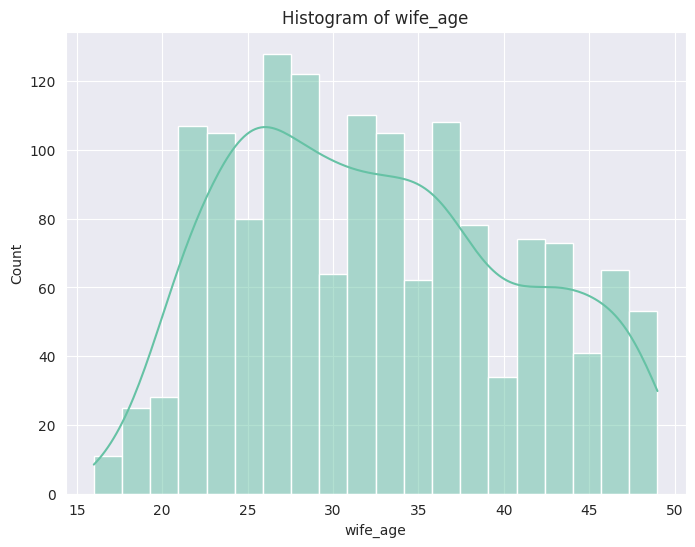

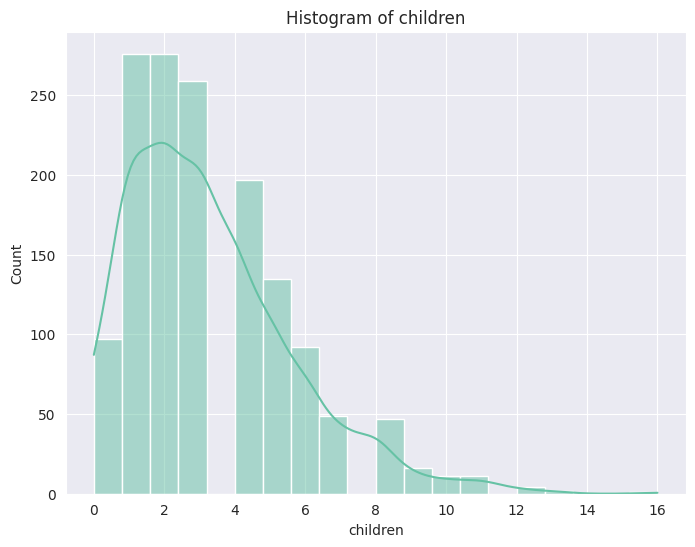

In [ ]:
sns.set_style('darkgrid')
sns.set_palette('Set2')

# First, we make a copy of the dataset to decode the variables (for visualization purposes)
dataC = data.copy()

#Function to create and display histogram
def HistogramPlot(x, title=None, xlabel=None, bins=None):

  #Creating a figure specyfying the sound
    plt.figure(figsize=(8, 6))
    sns.histplot(x, bins=bins, kde=True)

    #Adding title and labels to the plot
    plt.title(title)
    plt.xlabel(xlabel)

    #Displaying the plot
    plt.show()

# Create histograms for 'wife_age' and 'children'
for col in ['wife_age', 'children']:
    HistogramPlot(data[col], title=f'Histogram of {col}', xlabel=col, bins=20)


The middle 50% of the wife_age resides between 26 age to 39 age as can be seen from the box plot.

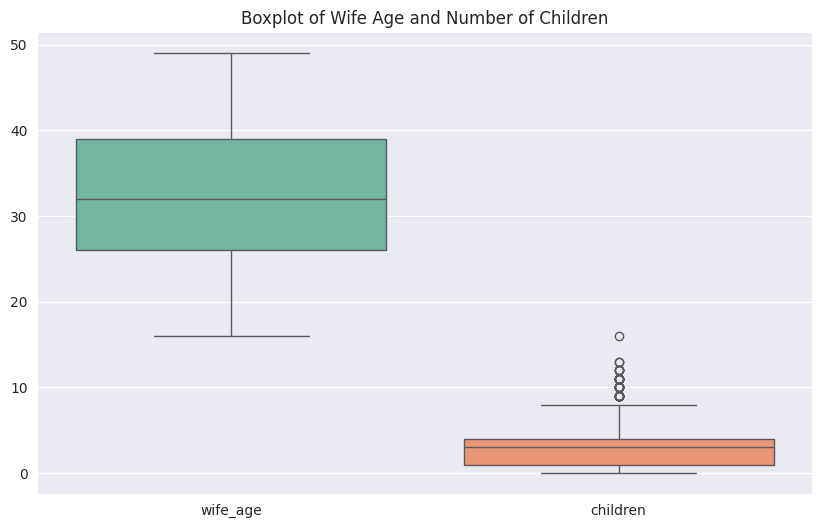

In [ ]:
#boxplot visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=dataC[['wife_age', 'children']])
plt.title('Boxplot of Wife Age and Number of Children')
plt.show()

To gain a sense of our data this is a graph showing the contraceptive method used against the number of womn. The most popular form was ​non-usage with 629 instances, followed by 511 women using ​short-term​ options while 333 women used ​long-term​ contraceptives.

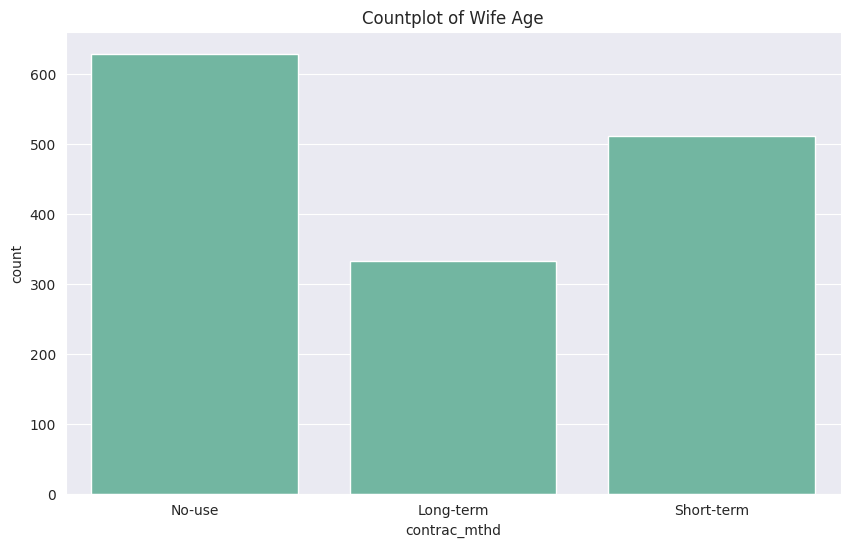

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='contrac_mthd', data=dataC)
plt.title('Countplot of Wife Age')
plt.show()

##Visualization for categorical attributes

### Visualization using pie Chart

Sort each attribute into a category using pie charts. Its powerful visual aid for its clarity and ease of comprehension

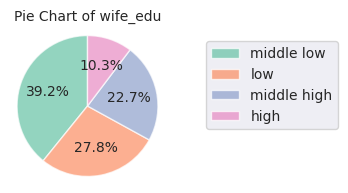

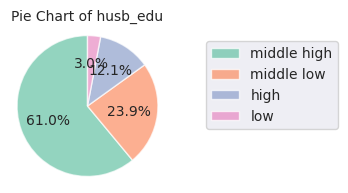

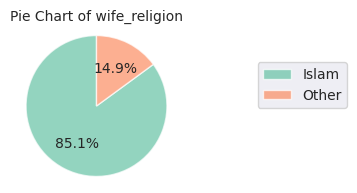

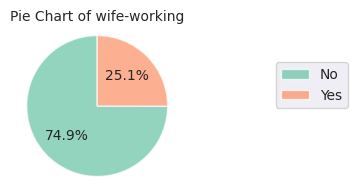

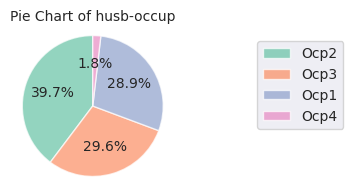

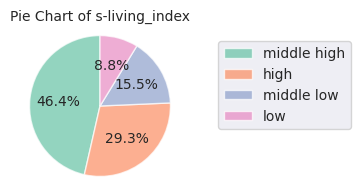

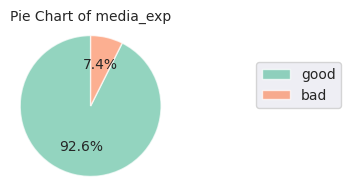

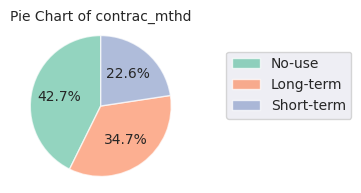

In [ ]:
# Loop through each column in the dataset
for col in data.columns:

  #Checking if the column has an object
    if (data[col].dtype.name == 'object'):

        # Create a pie chart for each categorical column
        data[col].value_counts().plot(
            kind='pie', fontsize=10, autopct='%.1f%%',
            pctdistance=0.6, startangle=90, labels=None,
            wedgeprops={'alpha': 0.7, 'edgecolor': 'white'},
            figsize=(2, 2)
        )

        plt.ylabel('')
        plt.axis('equal')

        #Creating a legent outside the pie chart
        plt.legend(labels=data[col].unique(), bbox_to_anchor=(1.8, 0.6), loc="center right",
                   fontsize=10, bbox_transform=plt.gcf().transFigure)
        plt.title('Pie Chart of ' + col, size=10)

        # Display each pie chart
        plt.show()

### Visualization of Categorical Features on a count barplot

Using Barplots to categorize each attribute displaying the frequency of contraceptive methods used per group defined by different categorical features

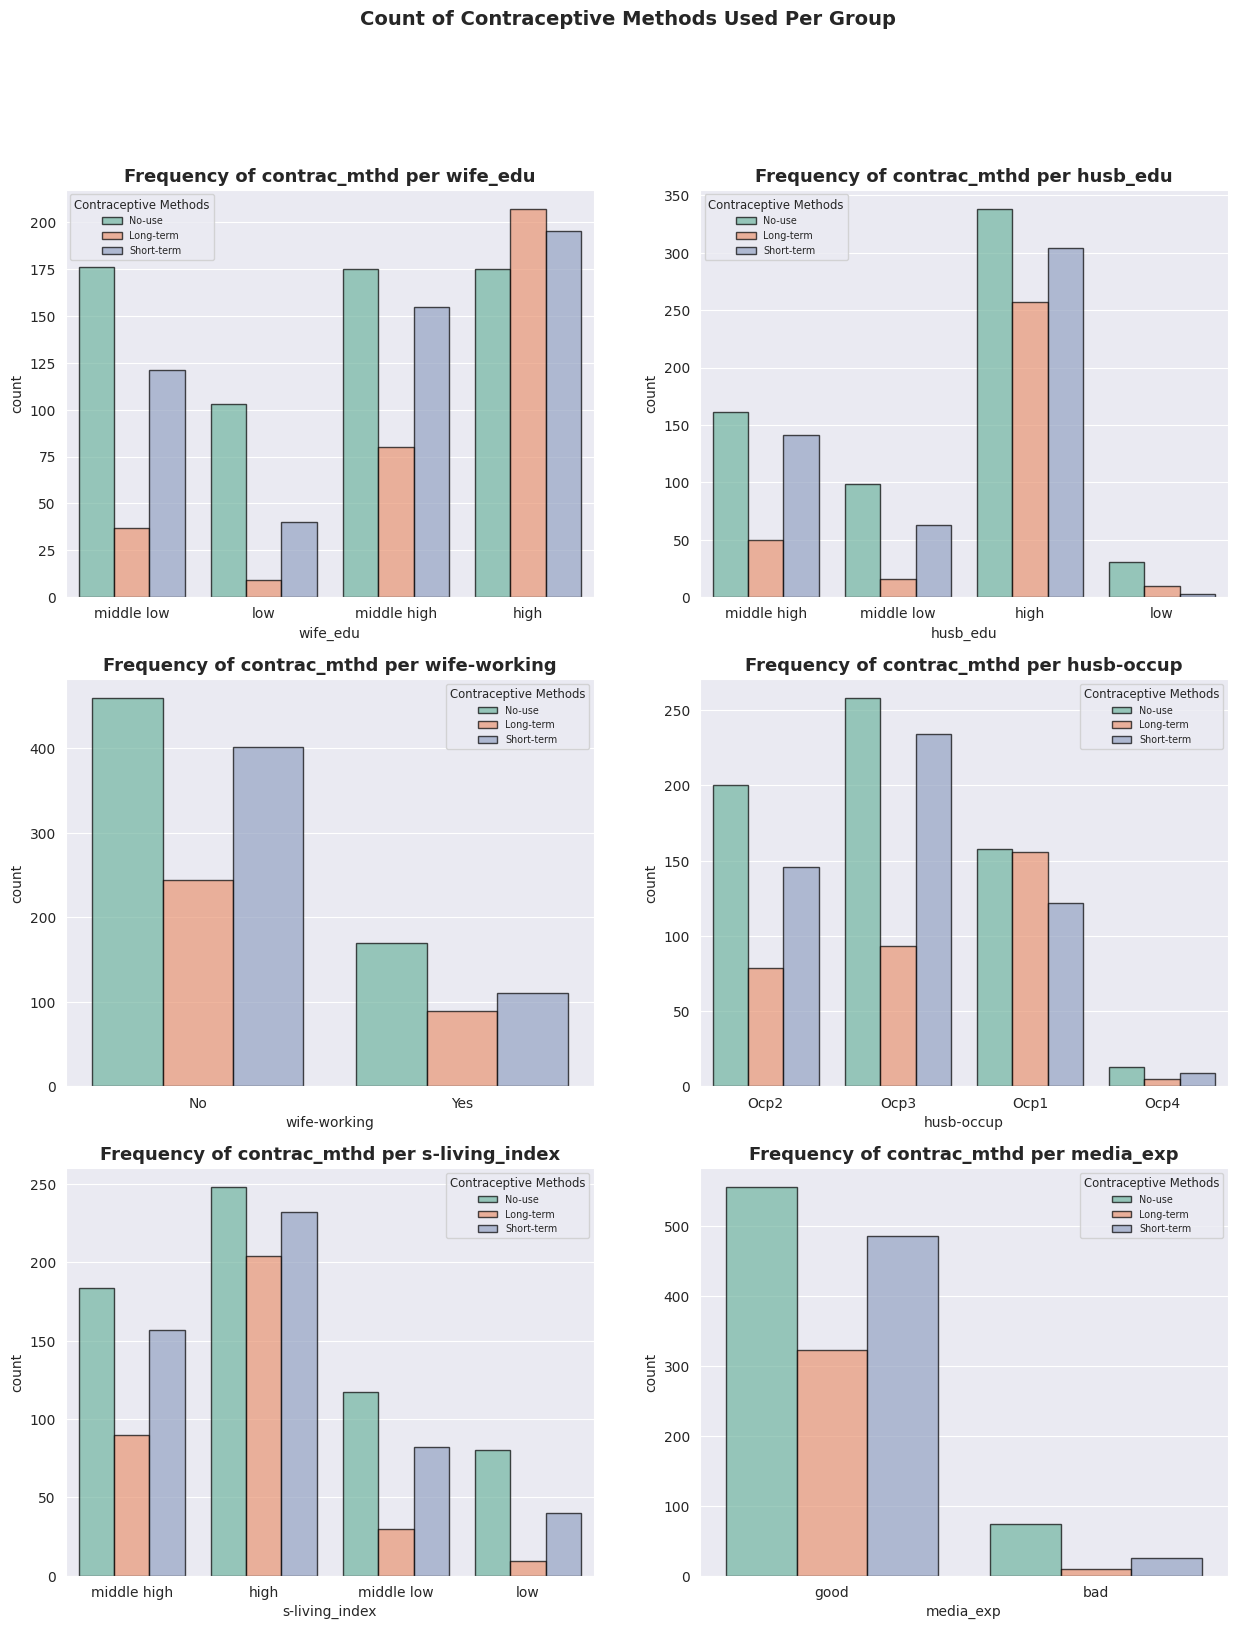

In [ ]:
# Set the style and color palette for the seaborn plots
sns.set_style('darkgrid')
sns.set_palette('Set2')

#Creating subplots
fig, ax = plt.subplots(3, 2, figsize=(15,18))

for col, ax in zip(['wife_edu', 'husb_edu', 'wife-working','husb-occup','s-living_index',
                    'media_exp'], ax.flatten()):
    sns.countplot(x=col, hue='contrac_mthd', data=data, ax=ax,alpha=0.7,edgecolor="black")

    #Set them main title
    fig.suptitle("Count of Contraceptive Methods Used Per Group", weight='bold', size=14)

    #Setting individual titles
    ax.set_title("Frequency of contrac_mthd per " + col,
                 weight='bold', size=13)

    #Adding a legent with text and title
    ax.legend(prop = {'size':'x-small'}).set_title('Contraceptive Methods',
                                                   prop = {'size':'small'})

Using Barplots to categorize each attribute.  It's noticeable that women with lower levels of education tend to use temporary solutions when they are younger and stop using them as they get older. The majority of category features indicate that families with three to six children utilize both short- and long-term contraceptive methods.

### Categorical Features on a count boxplot

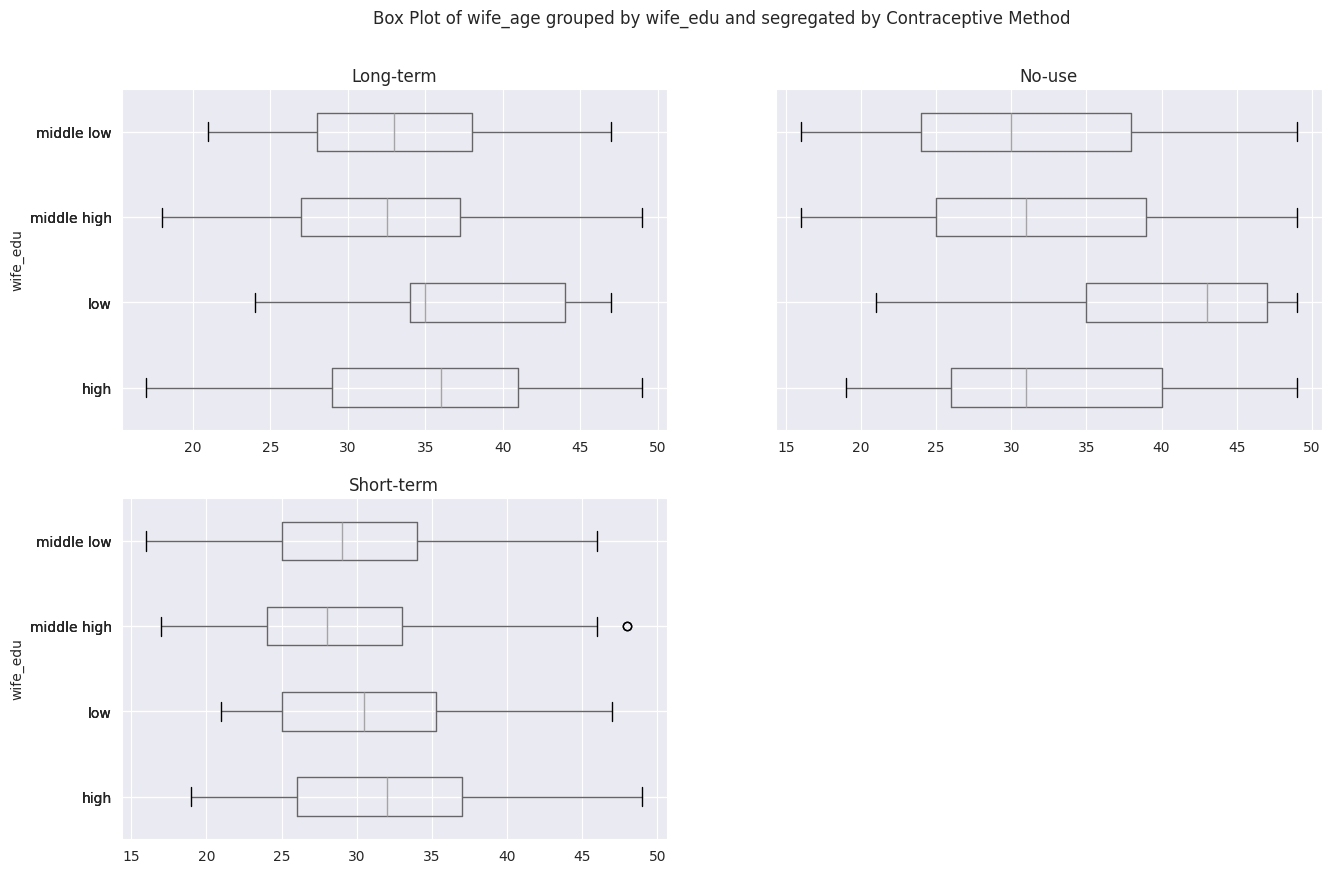

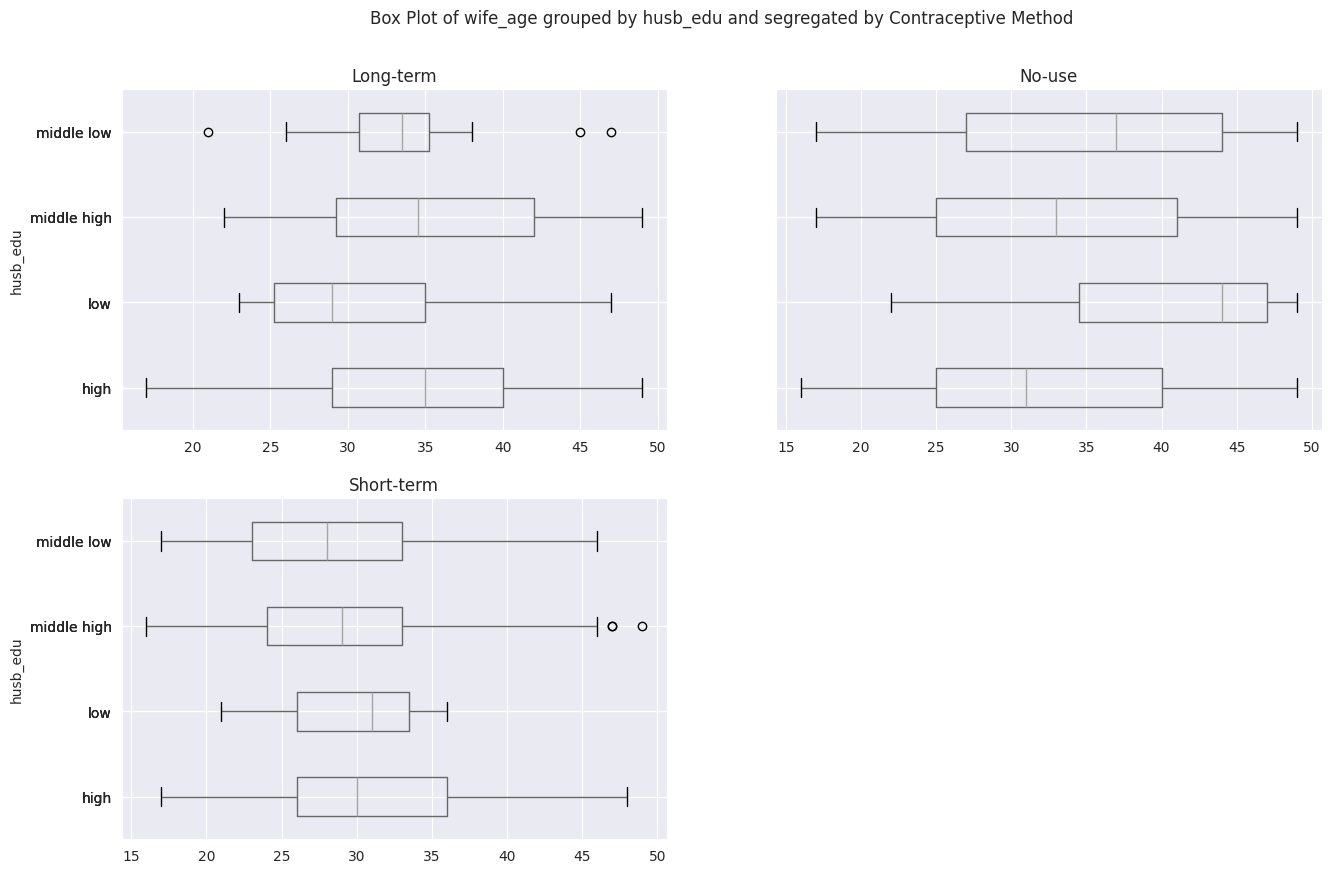

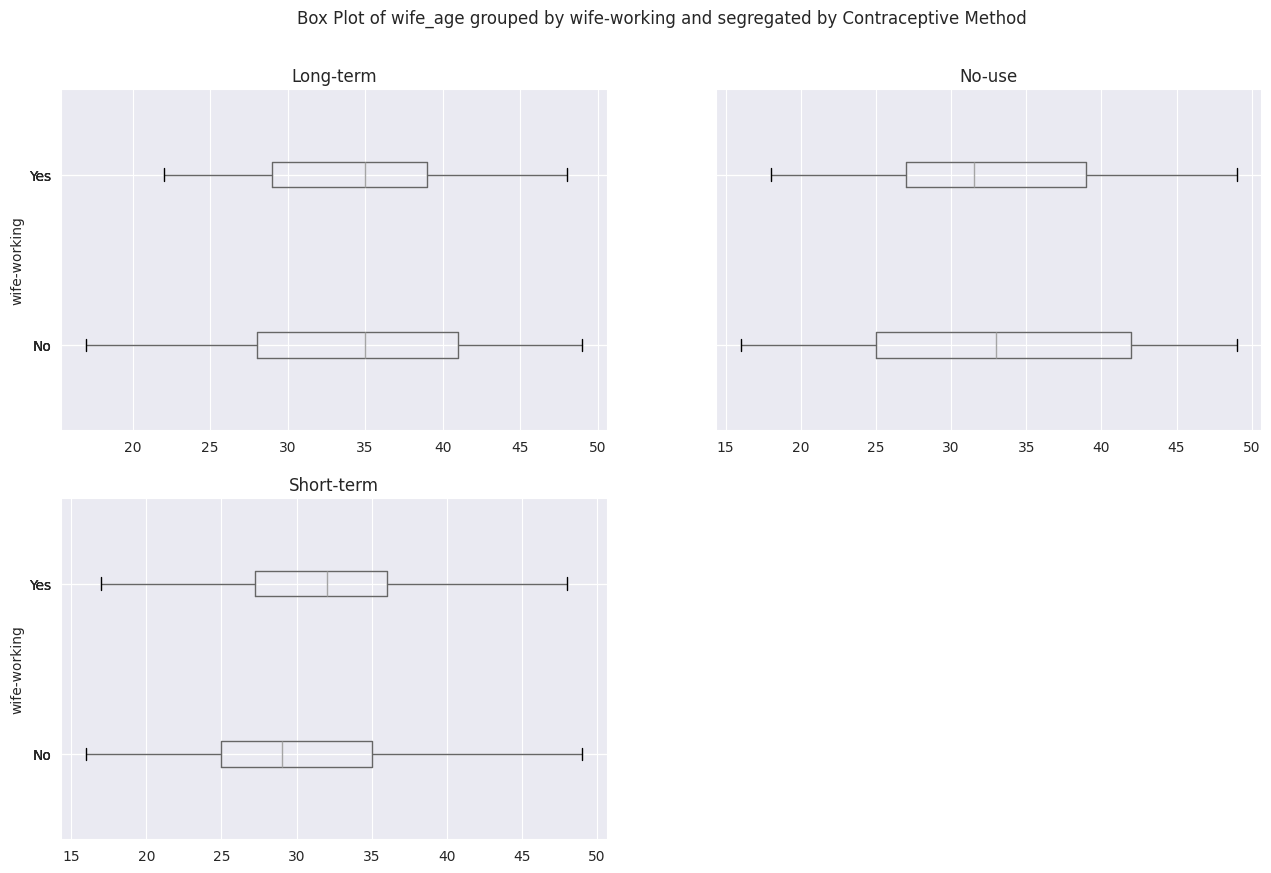

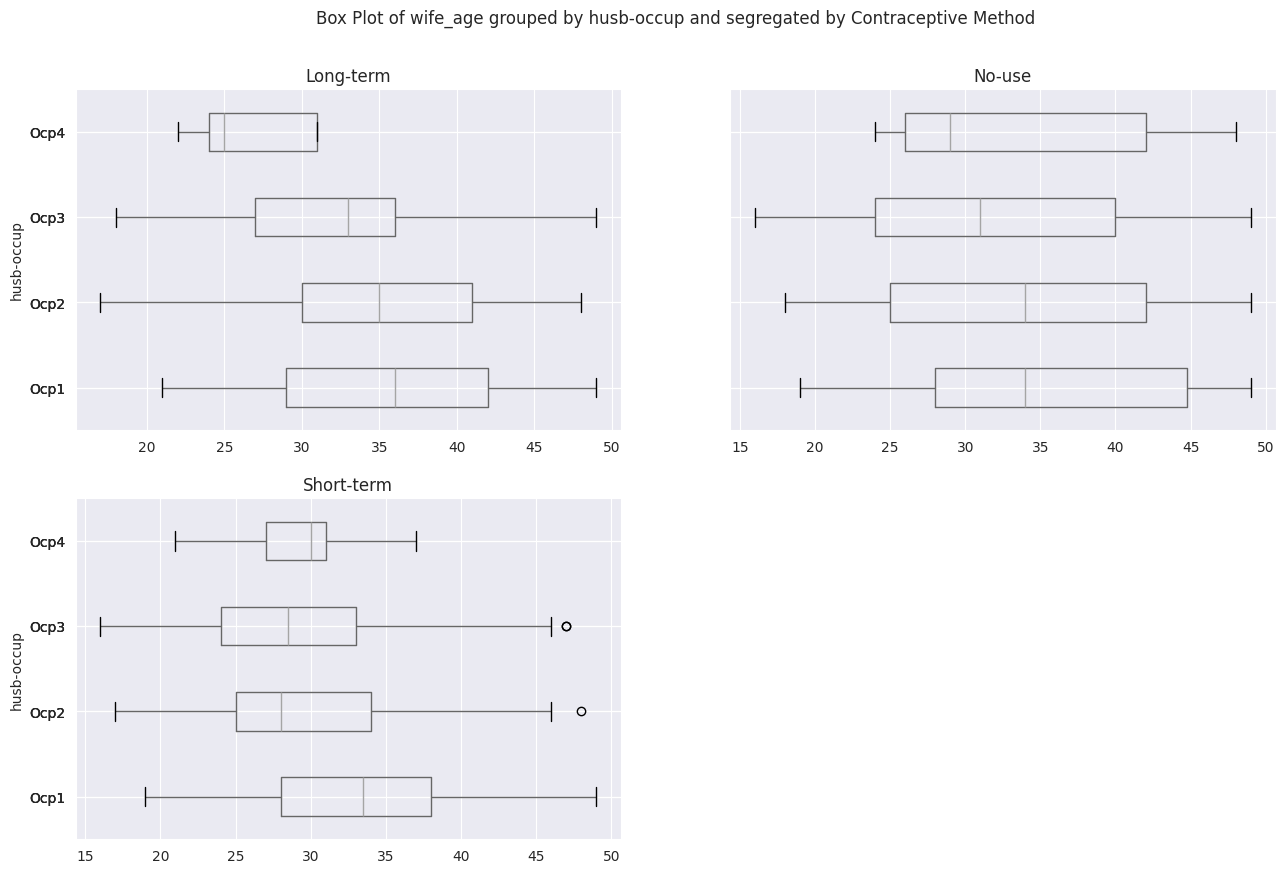

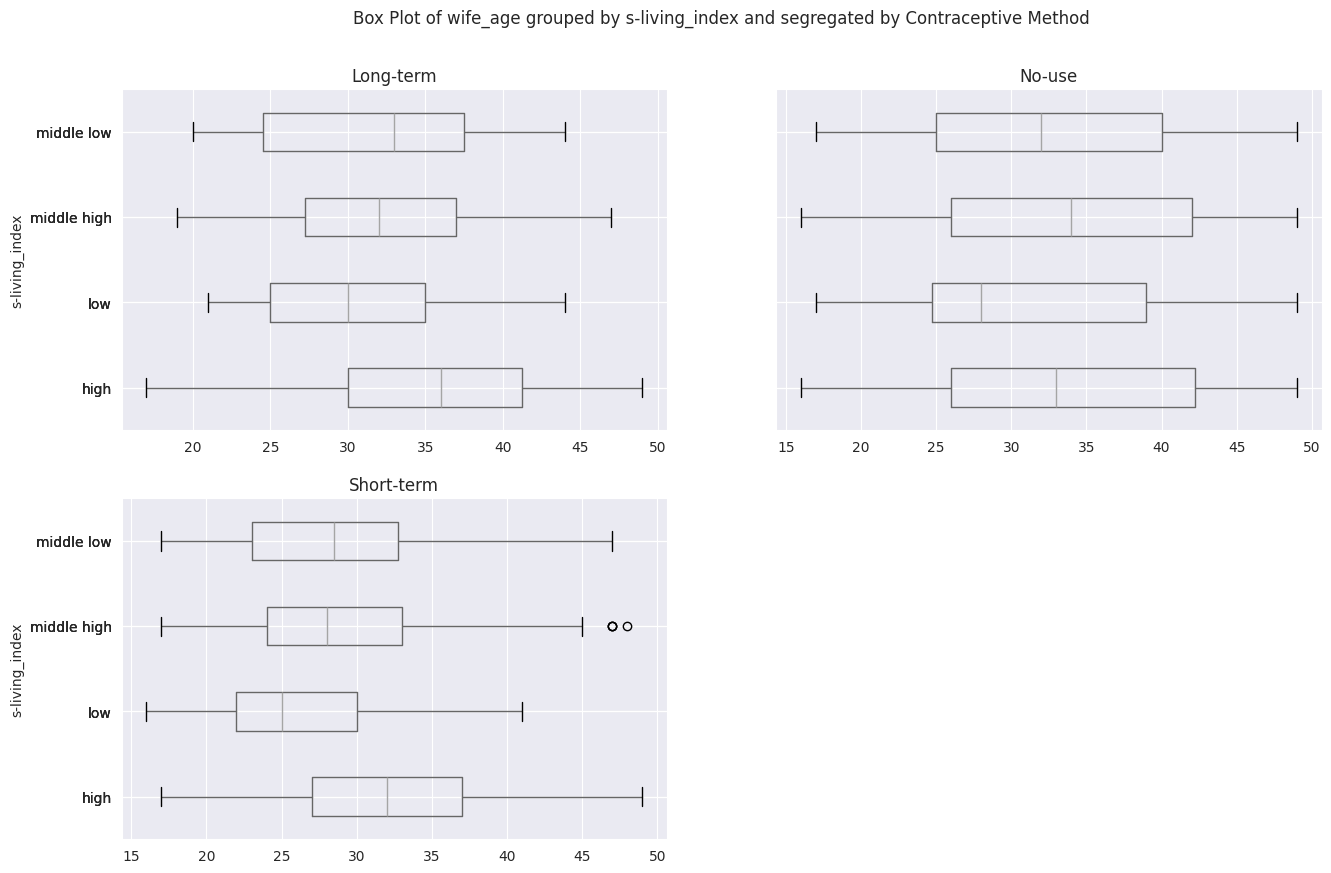

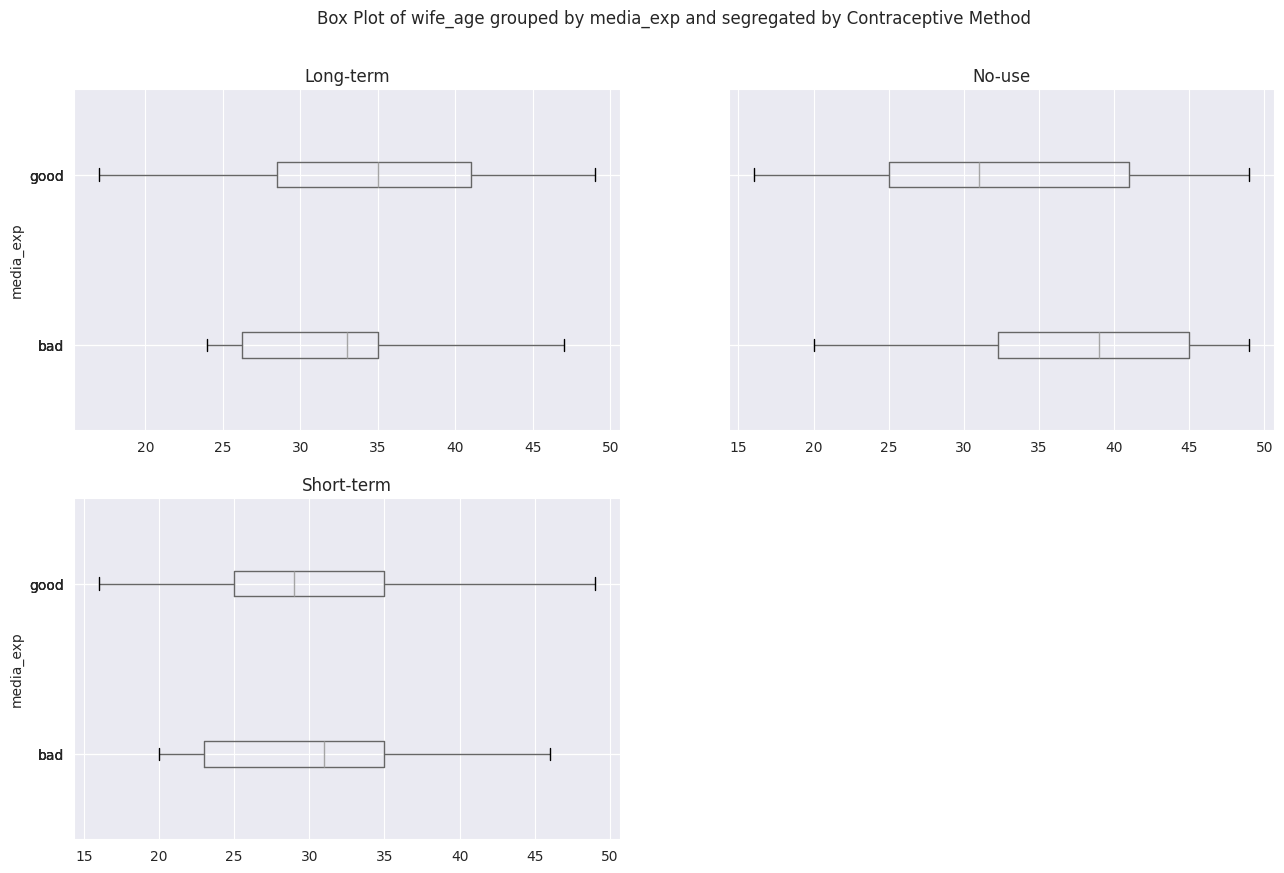

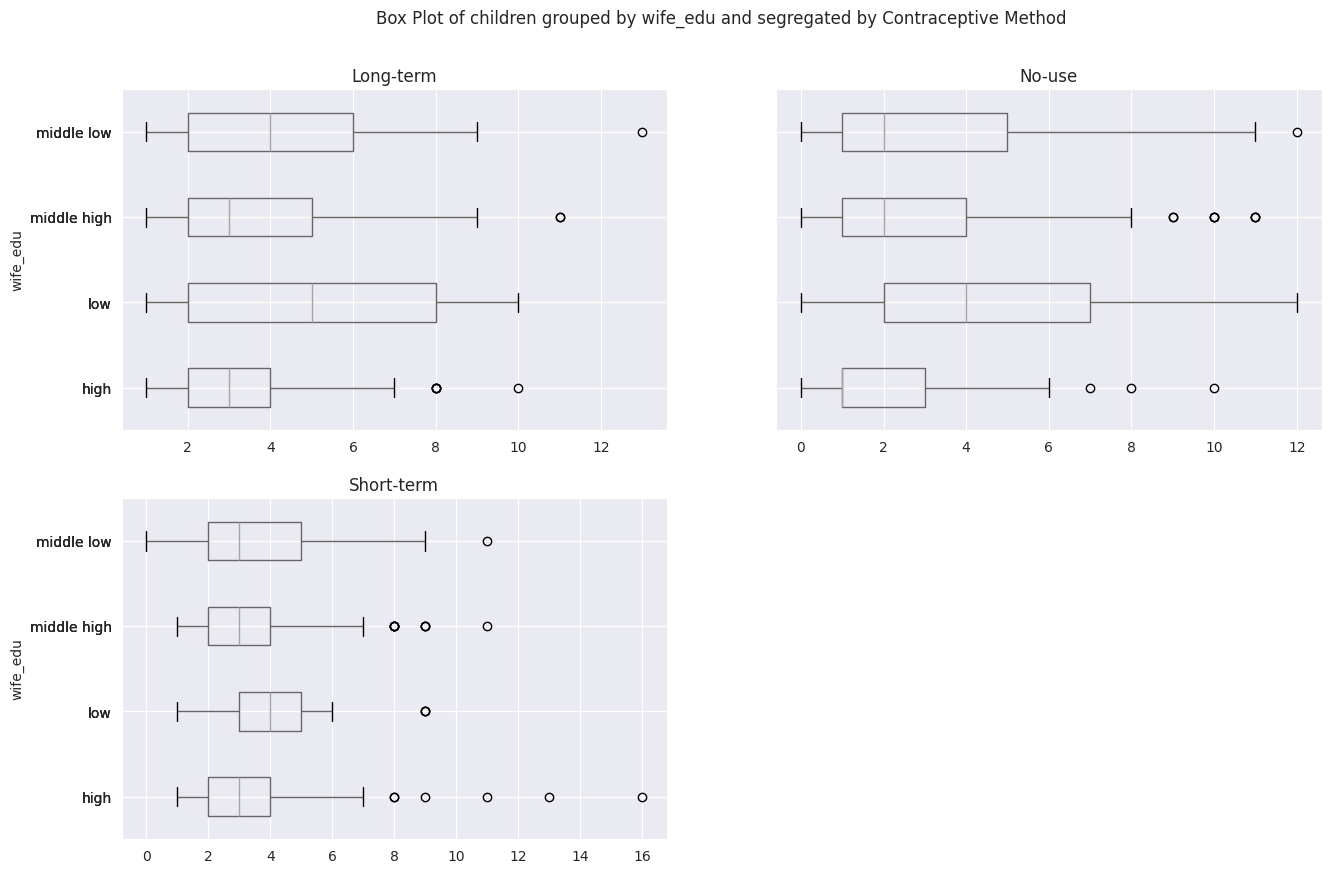

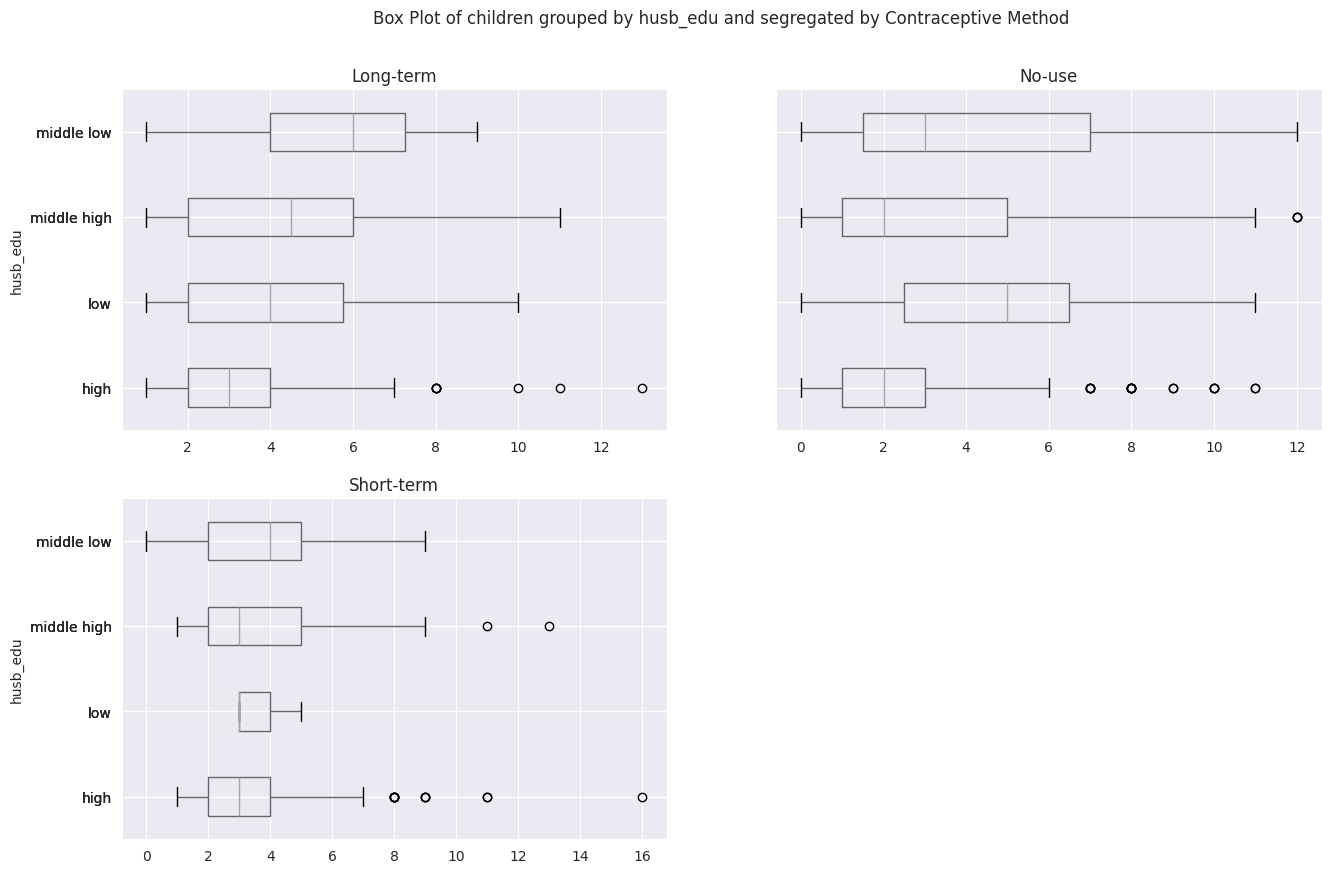

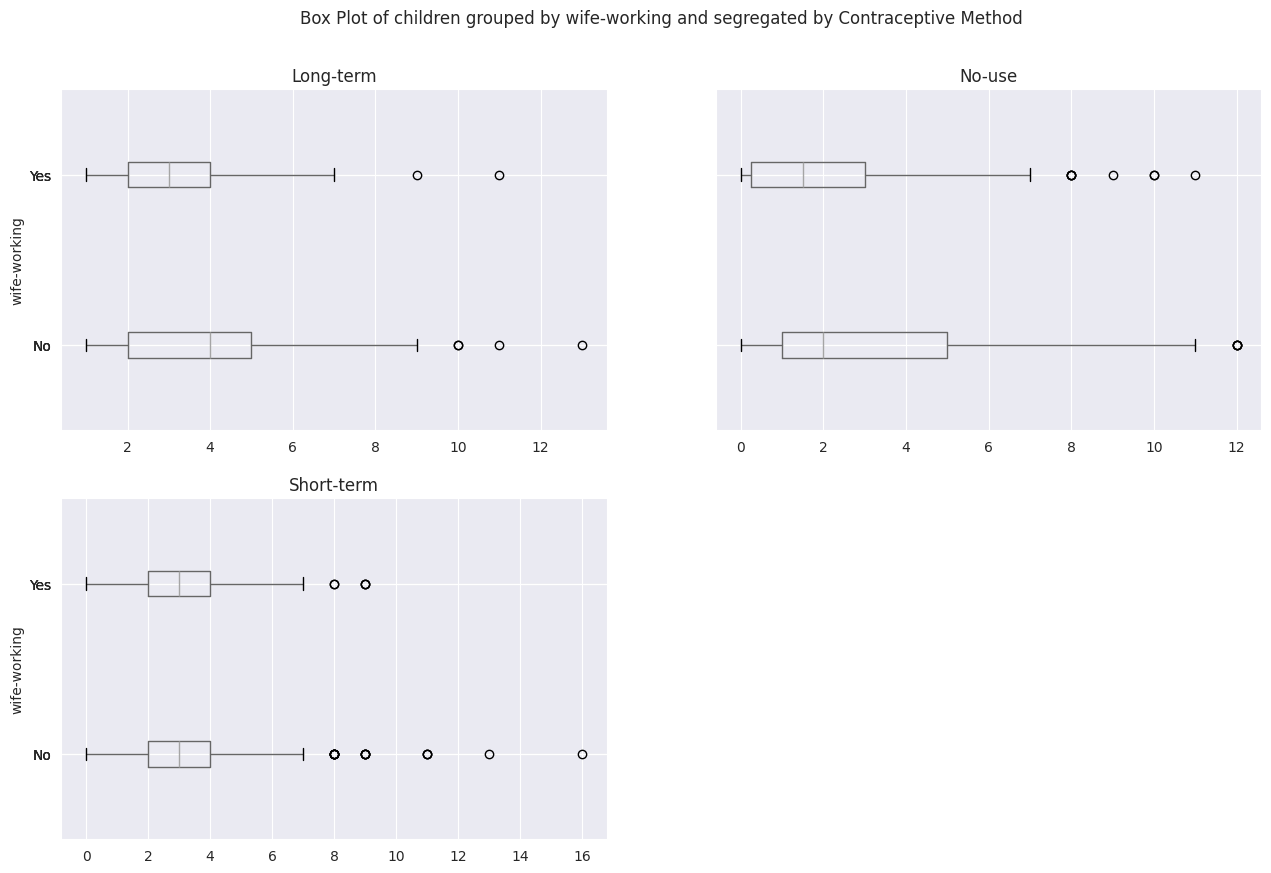

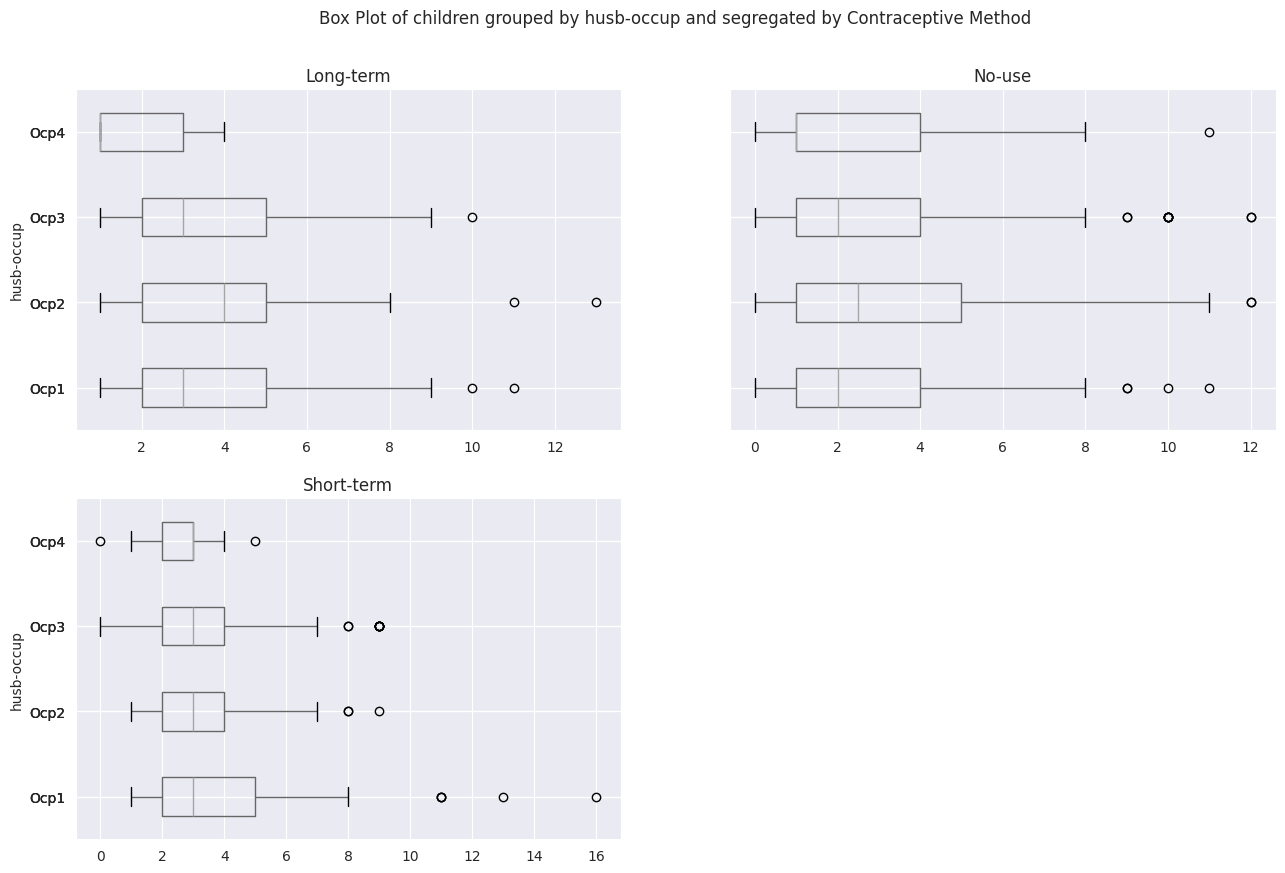

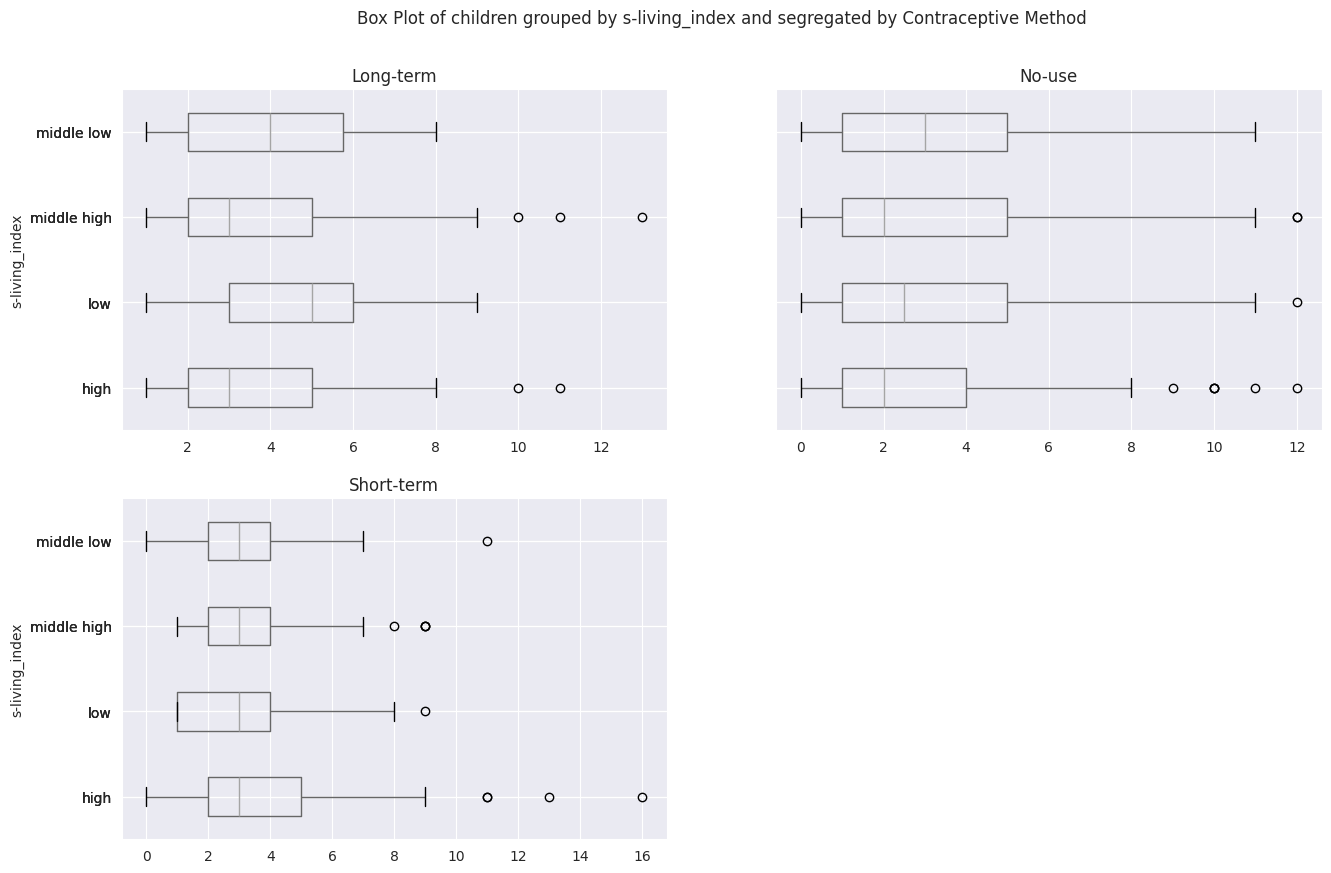

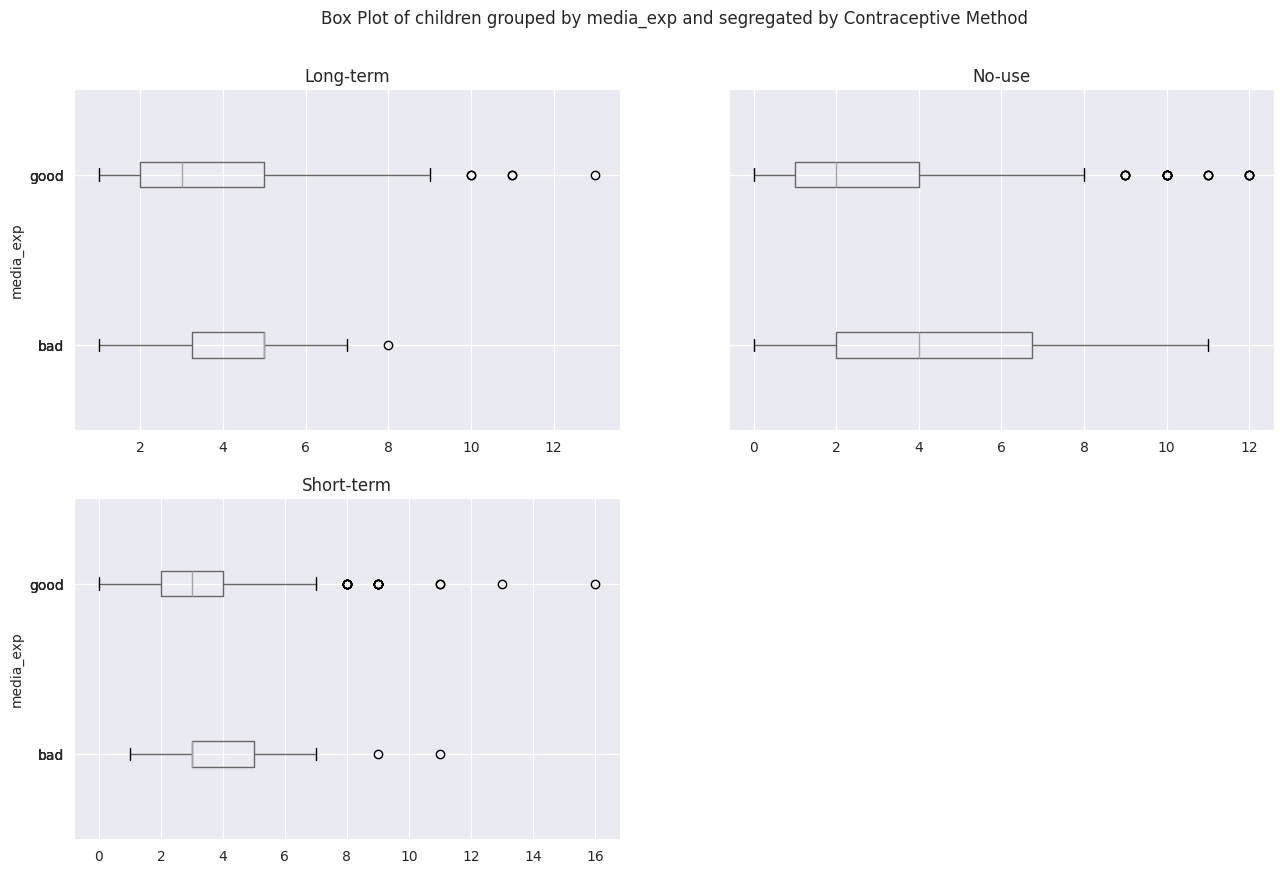

In [ ]:
# Nested loop to create boxplots for selected columns and groupings
for col in ['wife_age','children']:
    for k in ['wife_edu', 'husb_edu', 'wife-working','husb-occup','s-living_index','media_exp']:

      # Group data by 'contrac_mthd' and create boxplots for 'col' by 'k'
        ax = data.groupby('contrac_mthd').boxplot(column = col, by = k, vert = False, figsize=(15,10))

        #Settin title for boxplot
        plt.suptitle("Box Plot of " + col + " grouped by " + k +
                     " and segregated by Contraceptive Method")
        plt.yticks()
        plt.show()

#Data Preparation

ReExamining the dataset

In [ ]:
#Dataset dimension
contr_data=pd.read_csv('cmc.data',names=[ 'wife_age', 'wife_edu', 'husb_edu', 'children', 'wife_religion', 'wife-working', 'husb-occup',
                                       's-living_index', 'media_exp', 'contrac_mthd'])
contr_data.head()

,wife_age,wife_edu,husb_edu,children,wife_religion,wife-working,husb-occup,s-living_index,media_exp,contrac_mthd
0,24,2,3,3,1,1,2,3,0,1
1,45,1,3,10,1,1,3,4,0,1
2,43,2,3,7,1,1,3,4,0,1
3,42,3,2,9,1,1,3,3,0,1
4,36,3,3,8,1,1,3,2,0,1


###Missing Values
Most datasets will have some form of missing values. So, it is important to check for any missing.


In [ ]:
contr_data.isnull().sum()

,0
wife_age,0
wife_edu,0
husb_edu,0
children,0
wife_religion,0
wife-working,0
husb-occup,0
s-living_index,0
media_exp,0
contrac_mthd,0


In [ ]:
contr_data.info

<bound method DataFrame.info of       wife_age  wife_edu  husb_edu  children  wife_religion  wife-working  \
0           24         2         3         3              1             1   
1           45         1         3        10              1             1   
2           43         2         3         7              1             1   
3           42         3         2         9              1             1   
4           36         3         3         8              1             1   
...        ...       ...       ...       ...            ...           ...   
1468        33         4         4         2              1             0   
1469        33         4         4         3              1             1   
1470        39         3         3         8              1             0   
1471        33         3         3         4              1             0   
1472        17         3         3         1              1             1   

      husb-occup  s-living_index  media_exp  contrac_mthd  
0              2               3          0             1  
1              3               4          0             1  
2              3               4          0             1  
3              3               3          0             1  
4              3               2          0             1  
...          ...             ...        ...           ...  
1468           2               4          0             3  
1469           1               4          0             3  
1470           1               4          0             3  
1471           2               2          0             3  
1472           2               4          0             3  

[1473 rows x 10 columns]>

##Splitting data-set into the set of descriptive features and the target

Before encoding the target feature, it is required to split the data-set into descriptive features and the target feature. Then the target feature has been examined to see the distribution of each label

In [ ]:
dataC = contr_data.copy()
data = dataC.drop(columns = 'contrac_mthd')
target = dataC['contrac_mthd']

#Checking the count of instances
target.value_counts()

,count
contrac_mthd,
1,629
3,511
2,333


In [ ]:
data.sample(8)

,wife_age,wife_edu,husb_edu,children,wife_religion,wife-working,husb-occup,s-living_index,media_exp
746,31,2,3,7,1,1,3,3,0
934,46,4,4,4,0,1,1,4,0
164,34,4,4,4,1,1,2,3,0
1316,44,2,3,1,0,1,2,4,0
100,27,1,2,4,1,1,3,1,1
1008,49,4,4,1,1,1,3,4,0
1163,41,3,4,3,0,1,2,4,0
687,36,4,4,6,0,1,1,2,1


## Encoding Target
The target feature has been encoded to numeric values

In [ ]:
#Encoding Target
from sklearn import preprocessing
target = preprocessing.LabelEncoder().fit_transform(target)

#Checking the encoding
print(type(target))
np.unique(target, return_counts = True)

<class 'numpy.ndarray'>


(array([0, 1, 2]), array([629, 333, 511]))

In [ ]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


## Scaling Numerical data
In order to change characteristics by scaling them to have a mean of 0 and a standard deviation of 1, standardization is a preprocessing technique used in data analysis and machine learning.

In [ ]:
from sklearn import preprocessing

Data_scaler = preprocessing.MinMaxScaler()
Data_scaler.fit(data)
Data = Data_scaler.fit_transform(data)

## Feature Selection & Ranking using random forest

This section examines the top six characteristics of the dataset using Random Forest Importance (RFI) to provide a brief summary of each feature's significance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
num_features = 6
model_rfi = RandomForestClassifier(n_estimators=100)
model_rfi.fit(Data, target)
fs_indices_rfi = np.argsort(model_rfi.feature_importances_)[::-1][0:num_features]

best_features_rfi = dataC.columns[fs_indices_rfi].values
best_features_rfi

array(['wife_age', 'children', 's-living_index', 'husb-occup', 'wife_edu',
       'husb_edu'], dtype=object)

In [ ]:
feature_importances_rfi = model_rfi.feature_importances_[fs_indices_rfi]
feature_importances_rfi

array([0.35117799, 0.22902269, 0.0908638 , 0.08706537, 0.08503738,
       0.06629708])

In [ ]:
import altair as alt
alt.renderers.enable('colab')
def plot_imp(best_features, scores, method_name, color):

    df = pd.DataFrame({'features': best_features,
                       'importances': scores})

    chart = alt.Chart(df,
                      width=500,
                      title=method_name + ' Feature Importances'
                     ).mark_bar(opacity=0.85,
                                color=color).encode(
        alt.X('features', title='Feature', sort=None, axis=alt.AxisConfig(labelAngle=45)),
        alt.Y('importances', title='Importance')
    )

    return chart

# Plotting
plot_imp(best_features_rfi, feature_importances_rfi, 'Random Forest', 'pink')


alt.Chart(...)

## Splitting the dataframes

Splitting them the dataframe into the set of features (x) and the target (y)

In [ ]:
X = data
y = target

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(Data, target, test_size = 0.3,
                     stratify=target, shuffle=True, random_state=999)

print(X_train.shape)
print(X_test.shape)

(1031, 9)
(442, 9)


Splitting Data into Training and Test Sets

# Models

## Logistic Regression model

### Normalizing Data

In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
#Importing processing
from sklearn import preprocessing

#Normalize the data
normalized_X_train = preprocessing.normalize(X_train)
normalized_X_test = preprocessing.normalize(X_test)

### Create and Fit the Model

We use the LogisticRegression from the sklearn library to create the Logistic Regression Mode

In [ ]:
from sklearn.linear_model import LogisticRegression

#Initializing the regression model
lr_model = LogisticRegression(solver='lbfgs',max_iter=3000)

#Training the model on test data
lr_model.fit(X_train,y_train)

LogisticRegression(max_iter=3000)

### Predictions and Error Inspection

In [ ]:
# predicted values
y_pred = lr_model.predict(X_test)
# Storing the actual values
actual = y_test

In [ ]:
# create a dictionary and a data frame and check correct predictions
dic = {'Actual':actual,
'Prediction':y_pred,
'correct_prediction':0
}
result = pd.DataFrame(dic)

In [ ]:
# update the correct_prediction values to 1, if correct prediction
def myfunc(x,y):
  if x == y:
    return 1
  else:
    return 0
result['correct_prediction'] = result.apply(lambda x: myfunc(x.Actual, x.Prediction), axis=1)

In [ ]:
#Display rows with incorrect prediction
result[result.correct_prediction==0]

,Actual,Prediction,correct_prediction
2,1,0,0
5,2,1,0
9,1,0,0
10,1,0,0
11,2,0,0
...,...,...,...
286,1,0,0
288,0,1,0
289,2,1,0
293,2,0,0


## Decision Tree model

### Encoding

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Initialize the LabelEncoder
le = preprocessing.LabelEncoder()

### Splitting the dataset into training and testing

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [ ]:
# Print the shape of the training set for reference
print ('The shape of the training set is ',X_train.shape)

The shape of the training set is  (1178, 9)


### Create and fit the model

In [ ]:
# create an instance of the decision tree model
clf = DecisionTreeClassifier(max_depth = 2,
random_state = 0)

In [ ]:
# train the model (notice the parameters of the DecisionTreeClassifier)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=0)

### Prediction

In [ ]:
# Prediction for one instance (first one in the testing set)
label0 = clf.predict(X_test.iloc[0].values.reshape(1, -1))
# Predictions for the 10 instances in the testing set
labels_1_to_10= clf.predict(X_test[0:10])
# Predictions for the whole testing set
predictions = clf.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# create an instance of RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,)
# fit the model on training data
rf.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
# Predicted classes of the testing set
rf_predictions = rf.predict(X_test)
# get probabilities of predictions
rf_probs = rf.predict_proba(X_test)
# note rf_probs is a 2d numpy array
# show the class probs for the first image (note the output)
rf_probs[:1]

array([[0.99, 0.  , 0.01]])

# Model Evaluation

In [ ]:
# Import necessary libraries for model evaluation
# Get the model's accuracy
from sklearn.metrics import accuracy_score
print(f'The Overall Accuracy on Logistic Regression is {round(accuracy_score(y_test,y_pred) * 100,2)}%')
# Get the model's accuracy
accuracy = clf.score(X_test, y_test)
print(f'The overall accuracy of decision tree is {round(accuracy*100,2)}%')
accuracy = accuracy_score(y_test, rf_predictions)
print(f'The overall accuracy of Random forest is {np.round(accuracy*100,2)}%')

The Overall Accuracy on Logistic Regression is 51.19%
The overall accuracy of decision tree is 44.75%
The overall accuracy of Random forest is 52.88%


In [ ]:
from sklearn.metrics import confusion_matrix
print("\nConfusion Matrix for Logistic Regression")
print(confusion_matrix(y_test,y_pred))
print("\nClassification report for Random Forest")
print(confusion_matrix(y_test,rf_predictions))


Confusion Matrix for Logistic Regression
[[94  7 36]
 [22 22 31]
 [39  9 35]]

Classification report for Random Forest
[[91 20 26]
 [19 29 27]
 [31 16 36]]


In [ ]:
from sklearn import metrics
print("\nClassification report for Logistic regression")
print(metrics.classification_report(y_test, y_pred))
print("\nClassification report for Random Forest")
print(metrics.classification_report(y_test, rf_predictions))


Classification report for Logistic regression
              precision    recall  f1-score   support

           0       0.61      0.69      0.64       137
           1       0.58      0.29      0.39        75
           2       0.34      0.42      0.38        83

    accuracy                           0.51       295
   macro avg       0.51      0.47      0.47       295
weighted avg       0.53      0.51      0.50       295


Classification report for Random Forest
              precision    recall  f1-score   support

           0       0.65      0.66      0.65       137
           1       0.45      0.39      0.41        75
           2       0.40      0.43      0.42        83

    accuracy                           0.53       295
   macro avg       0.50      0.49      0.50       295
weighted avg       0.53      0.53      0.53       295



# Summary
Contraceptive method data-set is a multi-class classification problem and Decision trees (DT), Logistic Regression (LR) and Random Forest (RF) classifiers have been examined for this classification problem.

When evaluating the training set, the DT model with 6 of the best features selected by Random Forest Importance (RFI) produces the highest cross-validated accuracy score. Similarly, when evaluating the test set, the DT model performed the best on accuracy score of approximately 51.19%. Therefore, it can be concluded that the LR method is the most suitable model for this classification problem based on the given data-set.

# References
1.	Google Colaboratory, 2019. [online]. Google.com. Available from: https://colab.research.google.com/github/hossainlab/pandas/blob/master/book/notebooks/06-Renaming%20Columns%20and%20Replace%20Value.ipynb [Accessed 6 Dec 2023].
2.	Google Colaboratory, 2019. [online]. Google.com. Available from: https://colab.research.google.com/drive/11Gd3rmm7TR-ugw4blV6RRko-zf-d6fmF [Accessed 6 Dec 2023].
3.	Discretizing numeric attributes, 2022. [online]. FutureLearn. Available from: https://www.futurelearn.com/info/courses/more-data-mining-with-weka/0/steps/29113#:~:text=Share%20this%20post-,Discretizing%20is%20transforming%20numeric%20attributes%20to%20nominal.,decision%20tree%20(very%20likely). [Accessed 6 Dec 2023].
4.	RAY, S., 2015. 8 Ways to Improve Accuracy of Machine Learning Models (Updated 2023). [online]. Analytics Vidhya. Available from: https://www.analyticsvidhya.com/blog/2015/12/improve-machine-learning-results/ [Accessed 6 Dec 2023].
5.	ALVAREZ, martin, 2023. 7. Exploratory Data Analysis (EDA). [online]. Deepnote. Available from: https://deepnote.com/@martin-alvarez-59be/7-Exploratory-Data-Analysis-EDA-423db783-8258-448d-852a-21134de097ca [Accessed 6 Dec 2023].
6.	WEI HAO KHOONG, 2023. Why Scaling Your Data Is Important - CodeX - Medium. [online]. Medium. CodeX. Available from: https://medium.com/codex/why-scaling-your-data-is-important-1aff95ca97a2#:~:text=Data%20scaling%20is%20the%20process,the%20performance%20of%20the%20algorithm. [Accessed 7 Dec 2023].
